In [1]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
import tensorflow as tf 
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

2026-05-05 10:06:46.123034: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 10:06:46.125650: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 10:06:46.182144: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 10:06:46.183045: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 10:06:47.551269: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter": 250})
    plt.plot(res["loss_history"])
    plt.show()

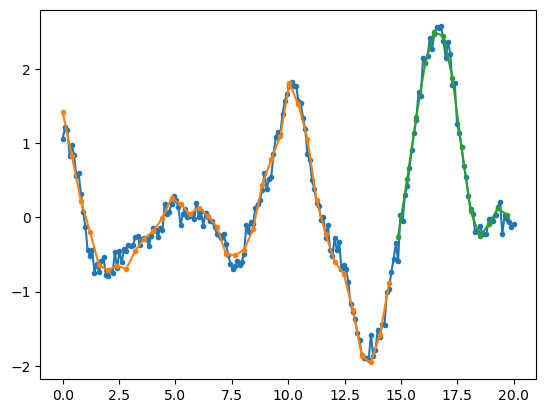

In [3]:
k = gpf.kernels.RBF(lengthscales=1, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.linspace(0, 20, 200)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.array([i for i in ind_1 if i % 4 == 0])
ind_1 = ind_1
ind_2 = ind_2
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2
y2 = y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.1, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.1, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

4
8
16
32
64
128
256
512


2026-05-05 10:06:57.865827: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


1024


2026-05-05 10:06:58.362601: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


2048


2026-05-05 10:06:59.578894: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


4096


2026-05-05 10:07:03.779411: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


[(<tf.Tensor: shape=(), dtype=float64, numpy=-55.673787120879815>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-53.22615735187747>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-51.24570952410532>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-46.232095563129576>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-45.73653768980781>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-45.90136234006114>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=-45.9013645557162>, <tf.Tensor: shape=(), dtype=float64, numpy=-46.838121475143126>), (<tf.Tensor: shape=(), dtype=float64, numpy=nan>, <tf.Tensor: shape=(), dtype=flo

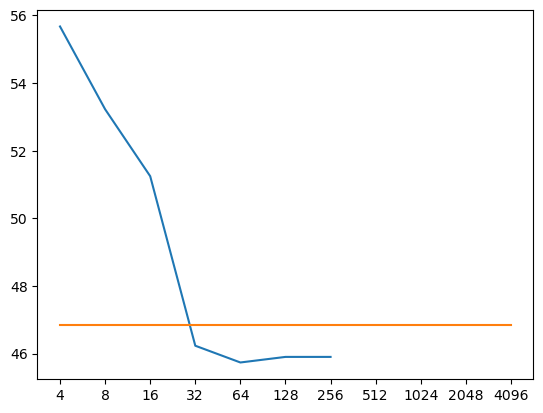

In [4]:
lmls = []
exponents = np.arange(2, 13)
for exponent in exponents:
    print(2 ** exponent)
    output_dim = 2  # Number of outputs
    rank = 1  # Rank of W
    k = gpf.kernels.RBF(lengthscales=1)

    # Base kernel

    # Coregion kernel
    coreg = gpf.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )
    ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
    iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
    shuffle = np.random.permutation(np.arange(len(ivs)))
    iv_ind = iv_ind[shuffle]
    ivs = np.hstack((ivs, iv_ind))
    kern = k * coreg
    m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
    kern = k * coreg
    m2 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
    lmls.append((m.maximum_log_likelihood_objective(), m2.maximum_log_likelihood_objective()))
print(lmls)
lmls = np.array(lmls)
plt.plot(exponents, -lmls[:,0])
plt.plot(exponents, -lmls[:,1])
plt.xticks(exponents, 2 ** exponents)
plt.show()

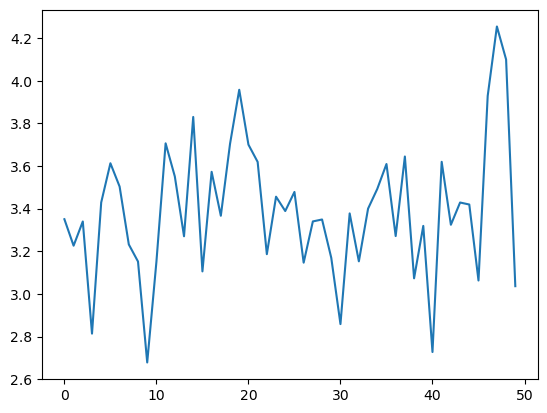

In [7]:
lmls = []

k = gpf.kernels.Matern12()
# Base kernel

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 10).reshape(-1, 1)
ivs_appended = ivs
iv_ind = np.concatenate((np.zeros((int(len(ivs_appended)/2),1)), np.ones(((len(ivs_appended) - int(len(ivs_appended)/2)),1))), -2)
shuffle = np.random.permutation(np.arange(len(ivs_appended)))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs_appended.reshape(-1, 1), iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
lml_start = m.maximum_log_likelihood_objective()

for i in np.linspace(0, 20, 50):
    output_dim = 2  # Number of outputs
    rank = 1  # Rank of W
    k = gpf.kernels.Matern12()
    # Base kernel

    # Coregion kernel
    coreg = gpf.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )
    ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
    ivs_appended = np.append(ivs, i)

    iv_ind = np.concatenate((np.zeros((int(len(ivs_appended)/2),1)), np.ones(((len(ivs_appended) - int(len(ivs_appended)/2)),1))), -2)
    shuffle = np.random.permutation(np.arange(len(ivs_appended)))
    iv_ind = iv_ind[shuffle]
    ivs = np.hstack((ivs_appended.reshape(-1, 1), iv_ind))
    kern = k * coreg
    m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
    #m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
    #gpf.set_trainable(m.kernel.kernels[0].variance, True)
    #gpf.set_trainable(m.inducing_variable.Z, False)

    lmls.append(m.maximum_log_likelihood_objective())

plt.plot(lmls - lml_start)